In [1]:
import pandas as pd
import numpy as np

# Đổi đường dẫn nếu cần
SALES_PATH = "../data/raw/sales.csv"
PROMO_PATH = "../data/raw/promotions.csv"

def run_data_check():
    print("="*50)
    print("1. KIỂM TRA MỨC ĐỘ TÀN PHÁ CỦA COVID")
    print("="*50)
    df_sales = pd.read_csv(SALES_PATH, parse_dates=["Date"])
    df_sales["Year"] = df_sales["Date"].dt.year
    
    # Tính trung bình doanh thu theo từng năm để xem COVID làm sụt giảm bao nhiêu %
    yearly_rev = df_sales.groupby("Year")["Revenue"].mean().astype(int)
    print("Trung bình doanh thu hàng ngày theo năm:")
    for year, rev in yearly_rev.items():
        if year in [2020, 2021]:
            print(f"  > {year} (COVID): {rev:,} VND")
        else:
            print(f"  > {year}: {rev:,} VND")
            
    print("\n" + "="*50)
    print("2. KIỂM TRA BIẾN ĐỘNG (Lý do phải dùng Log-Transform)")
    print("="*50)
    rev_mean = df_sales["Revenue"].mean()
    rev_std = df_sales["Revenue"].std()
    rev_max = df_sales["Revenue"].max()
    print(f"- Mean Revenue: {rev_mean:,.0f}")
    print(f"- Std Revenue : {rev_std:,.0f}")
    print(f"- Max Revenue : {rev_max:,.0f}")
    print(f"=> Nếu Std lớn hơn hoặc xấp xỉ Mean, và Max gấp chục lần Mean, thì KHÔNG THỂ để scale gốc cho XGBoost học Residual được!")

    print("\n" + "="*50)
    print("3. KIỂM TRA PROMOTION SHIFT (Cái FIX 1 trong feature_eng.py)")
    print("="*50)
    df_promo = pd.read_csv(PROMO_PATH, parse_dates=["start_date", "end_date"])
    
    # Check xem năm 2021, 2022 có bao nhiêu campaign để shift sang 2023, 2024
    promo_2021 = len(df_promo[df_promo["start_date"].dt.year == 2021])
    promo_2022 = len(df_promo[df_promo["start_date"].dt.year == 2022])
    print(f"- Số campaign năm 2021 (sẽ tịnh tiến lên 2023): {promo_2021}")
    print(f"- Số campaign năm 2022 (sẽ tịnh tiến lên 2024): {promo_2022}")
    if promo_2021 == 0 or promo_2022 == 0:
        print("!!! CẢNH BÁO: Không có đủ campaign để shift, tập Test 2023-2024 sẽ bị 'mù' tín hiệu khuyến mãi!")

if __name__ == "__main__":
    run_data_check()

1. KIỂM TRA MỨC ĐỘ TÀN PHÁ CỦA COVID
Trung bình doanh thu hàng ngày theo năm:
  > 2012: 4,096,672 VND
  > 2013: 4,540,190 VND
  > 2014: 5,128,344 VND
  > 2015: 5,177,900 VND
  > 2016: 5,750,384 VND
  > 2017: 5,236,066 VND
  > 2018: 5,068,828 VND
  > 2019: 3,114,524 VND
  > 2020 (COVID): 2,881,180 VND
  > 2021 (COVID): 2,857,643 VND
  > 2022: 3,204,791 VND

2. KIỂM TRA BIẾN ĐỘNG (Lý do phải dùng Log-Transform)
- Mean Revenue: 4,286,584
- Std Revenue : 2,624,840
- Max Revenue : 20,905,271
=> Nếu Std lớn hơn hoặc xấp xỉ Mean, và Max gấp chục lần Mean, thì KHÔNG THỂ để scale gốc cho XGBoost học Residual được!

3. KIỂM TRA PROMOTION SHIFT (Cái FIX 1 trong feature_eng.py)
- Số campaign năm 2021 (sẽ tịnh tiến lên 2023): 6
- Số campaign năm 2022 (sẽ tịnh tiến lên 2024): 4


PHÂN TÍCH XU HƯỚNG DỰ BÁO (SEABORN PRO EDITION)

=> Đã vẽ xong bản Seaborn! Bro mở file '../outputs/submission_trend_seaborn.png' lên chiêm ngưỡng nhé.


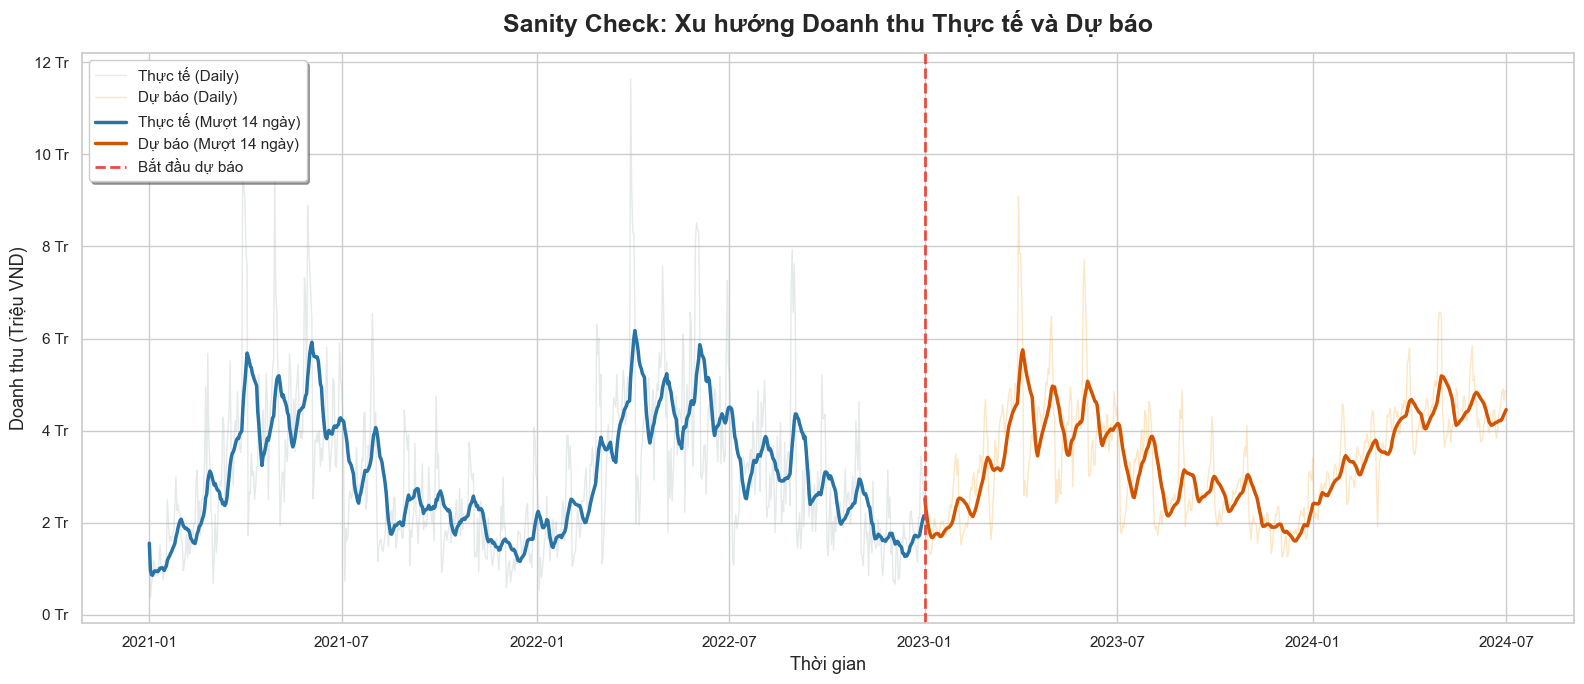

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def check_trends():
    print("="*60)
    print("PHÂN TÍCH XU HƯỚNG DỰ BÁO (SEABORN PRO EDITION)")
    print("="*60)
    
    # 1. Load Data
    try:
        df_actual = pd.read_csv("../data/raw/sales.csv", parse_dates=["Date"])
        df_sub = pd.read_csv("../outputs/submission.csv", parse_dates=["Date"])
    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file. {e}")
        return

    # Lọc lấy từ 2021 trở đi
    df_actual_recent = df_actual[df_actual["Date"] >= "2021-01-01"].copy()
    
    # Tính Rolling 14 ngày để làm mượt (khử nhiễu)
    df_actual_recent["Revenue_Roll14"] = df_actual_recent["Revenue"].rolling(14, min_periods=1).mean()
    df_sub["Revenue_Roll14"] = df_sub["Revenue"].rolling(14, min_periods=1).mean()

    # 2. Setup Seaborn xịn xò
    sns.set_theme(style="whitegrid", palette="muted")
    plt.figure(figsize=(16, 7))
    
    # Vẽ data gốc (chìm xuống làm nền với alpha thấp)
    sns.lineplot(x=df_actual_recent["Date"], y=df_actual_recent["Revenue"], color="#aab7b8", alpha=0.3, linewidth=1, label="Thực tế (Daily)")
    sns.lineplot(x=df_sub["Date"], y=df_sub["Revenue"], color="#f5b041", alpha=0.3, linewidth=1, label="Dự báo (Daily)")
    
    # Vẽ đường Rolling Mean (Nổi lên trên để dễ xem Trend)
    sns.lineplot(x=df_actual_recent["Date"], y=df_actual_recent["Revenue_Roll14"], color="#2874a6", linewidth=2.5, label="Thực tế (Mượt 14 ngày)")
    sns.lineplot(x=df_sub["Date"], y=df_sub["Revenue_Roll14"], color="#d35400", linewidth=2.5, label="Dự báo (Mượt 14 ngày)")

    # Đánh dấu điểm nối
    plt.axvline(pd.Timestamp("2023-01-01"), color="#e74c3c", linestyle="--", linewidth=2, label="Bắt đầu dự báo")

    # Tút tát label và title
    plt.title("Sanity Check: Xu hướng Doanh thu Thực tế và Dự báo", fontsize=18, fontweight='bold', pad=15)
    plt.xlabel("Thời gian", fontsize=13)
    plt.ylabel("Doanh thu (Triệu VND)", fontsize=13)
    
    # Format lại trục Y cho dễ đọc (Ví dụ: 12,000,000 -> 12 Tr)
    def millions_formatter(x, pos):
        return f'{x*1e-6:,.0f} Tr'
    plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))

    # Tinh chỉnh legend
    plt.legend(fontsize=11, loc="upper left", frameon=True, shadow=True)
    plt.tight_layout()
    
    # Lưu file
    out_img = "../outputs/submission_trend_seaborn.png"
    plt.savefig(out_img, dpi=200)
    print(f"\n=> Đã vẽ xong bản Seaborn! Bro mở file '{out_img}' lên chiêm ngưỡng nhé.")

if __name__ == "__main__":
    check_trends()